In [1]:
print("123")

123


In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from openai import OpenAI
openai_client = OpenAI()


In [4]:
def llm(prompt):
    response = openai_client.responses.create(
        model="gpt-5.4-mini",
        input=prompt
    )
    return response.output_text

In [5]:
import os
from dotenv import load_dotenv
from openai import OpenAI

# This reads the .env file
load_dotenv() 

# This automatically fetches the GROQ_API_KEY from your environment
client = OpenAI(
    base_url="https://api.groq.com/openai/v1",
    api_key=os.environ.get("GROQ_API_KEY")
)

In [6]:
def llm(prompt):
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": prompt}]
    )
    
    return response.choices[0].message.content

In [7]:
llm("Hey, what's up?")

"Not much, just here and ready to help. What's on your mind? Want to chat about something or ask a question? I'm all ears."

In [8]:
question = "I just discovered the course. Can I join now?"
answer = llm(question)
print(answer)

I'd be happy to help you with your query. However, I need a bit more information about the course you're referring to. Could you please provide more context or details about the course, such as its name, duration, and any specific requirements or deadlines? That way, I can better understand your situation and provide a more accurate response.


In [9]:
context = """
I just discovered the course. Can I still join?
Yes, but if you want to receive a certificate, you need to submit your project while 
we're still accepting submissions.

Course: I have registered for the LLM Zoomcamp. When can I expect to receive the confirmation email?
You don't need it. You're accepted. You can also just start learning and submitting homework 
(while the form is open) without registering. It is not checked against any registered list. 
Registration is just to gauge interest before the start date.

What is the video/zoom link to the stream for the "Office Hours" or live/workshop sessions?
The zoom link is only published to instructors/presenters/TAs. Students participate 
via YouTube Live and submit questions to Slido.

Cloud alternatives with GPU
Check the quota and reset cycle carefully. Potential options include Google Colab, Kaggle, Databricks.
"""

In [10]:
prompt = f"""
Your task is to answer questions from the course participants
based on the provided context.

Use the context to find relevant information and provide accurate
answers. If the answer is not found in the context,
respond with "I don't know."

Question:
{question}

Context:
{context}
"""

In [11]:
print(prompt)


Your task is to answer questions from the course participants
based on the provided context.

Use the context to find relevant information and provide accurate
answers. If the answer is not found in the context,
respond with "I don't know."

Question:
I just discovered the course. Can I join now?

Context:

I just discovered the course. Can I still join?
Yes, but if you want to receive a certificate, you need to submit your project while 
we're still accepting submissions.

Course: I have registered for the LLM Zoomcamp. When can I expect to receive the confirmation email?
You don't need it. You're accepted. You can also just start learning and submitting homework 
(while the form is open) without registering. It is not checked against any registered list. 
Registration is just to gauge interest before the start date.

What is the video/zoom link to the stream for the "Office Hours" or live/workshop sessions?
The zoom link is only published to instructors/presenters/TAs. Students part

In [12]:
answer = llm(prompt)
print(answer)

You can join the course now. However, if you want to receive a certificate, you need to submit your project while submissions are still being accepted.


In [13]:
def rag(question):
    search_results = search(question)
    user_prompt = build_prompt(question, search_results)
    return llm(user_prompt)

In [14]:
import requests
docs_url = "https://datatalks.club/faq/json/courses.json"
response =requests.get(docs_url)
course_raw=response.json()

In [15]:
course_raw[1]

{'course': 'stock-markets-analytics-zoomcamp',
 'course_name': 'Stock Markets Analytics Zoomcamp',
 'path': '/json/stock-markets-analytics-zoomcamp.json',
 'questions_count': 93}

In [16]:
documents = []
url_prefix = "https://datatalks.club/faq"
for course in course_raw:
    course_url = f"""{url_prefix}{course['path']}"""
    course_response = requests.get(course_url)
    course_response.raise_for_status()
    course_data= course_response.json()
    documents.extend(course_data)
len(documents)


1342

In [17]:
documents[1200]

{'id': '7915e5968b',
 'course': 'machine-learning-zoomcamp',
 'section': 'Module 8. Neural Networks and Deep Learning',
 'question': 'ValueError: Unable to load weights saved in HDF5 format into a subclassed Model',
 'answer': 'When loading a saved model, you encounter the error:\n\n```\nValueError: Unable to load weights saved in HDF5 format into a subclassed Model which has not created its variables yet. Call the Model first, then load the weights.\n```\n\n\nBefore loading the model, you need to evaluate the model on input data:\n\n```python\nmodel.evaluate(train_ds)\n```'}

In [18]:
from minsearch import Index
index= Index(
    text_fields=["question", "section", "answer"],
    keyword_fields=['course']
)
index.fit(documents)


In [19]:
search_results=index.search(question, 
             filter_dict={"course":"llm-zoomcamp"}, 
             num_results=5)

In [20]:
def search(question, course="llm-zoomcamp"):
    boost_dict = {"question": 2.0, "section": 0.5}
    filter_dict = {"course": course}
    
    return index.search(
        query=question,
        boost_dict=boost_dict,
        filter_dict=filter_dict,
        num_results=5
    )

In [21]:
search_results = search(question)
search_results

[{'id': '74eb249bbf',
  'course': 'llm-zoomcamp',
  'section': 'General Course-Related Questions',
  'question': 'I just discovered the course. Can I still join?',
  'answer': 'Yes, but if you want to receive a certificate, you need to submit your project while we’re still accepting submissions.'},
 {'id': '977bf7786c',
  'course': 'llm-zoomcamp',
  'section': 'General Course-Related Questions',
  'question': 'Course: I have registered for the LLM Zoomcamp. When can I expect to receive the confirmation email?',
  'answer': "You don't need it. You're accepted. You can also just start learning and submitting homework (while the form is open) without registering. It is not checked against any registered list. Registration is just to gauge interest before the start date."},
 {'id': '69d122f12e',
  'course': 'llm-zoomcamp',
  'section': 'General Course-Related Questions',
  'question': 'Certificate: Can I follow the course in a self-paced mode and get a certificate?',
  'answer': 'No, you c

In [22]:
response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[{"role": "user", "content": prompt}]
)

print(response.choices[0].message.content)

You can join the course now. However, if you want to receive a certificate, you need to submit your project while submissions are still being accepted.


In [23]:
# Dump the entire Groq API response structure to a clean JSON string
json_response = response.model_dump_json(indent=2)

# Print it so it formats beautifully with the indents
print(json_response)

{
  "id": "chatcmpl-5e5033e3-7ff1-45d7-9c88-ca7fdf190bfe",
  "choices": [
    {
      "finish_reason": "stop",
      "index": 0,
      "logprobs": null,
      "message": {
        "content": "You can join the course now. However, if you want to receive a certificate, you need to submit your project while submissions are still being accepted.",
        "refusal": null,
        "role": "assistant",
        "annotations": null,
        "audio": null,
        "function_call": null,
        "tool_calls": null
      }
    }
  ],
  "created": 1781544703,
  "model": "llama-3.3-70b-versatile",
  "object": "chat.completion",
  "moderation": null,
  "service_tier": "on_demand",
  "system_fingerprint": "fp_f8b414701e",
  "usage": {
    "completion_tokens": 31,
    "prompt_tokens": 283,
    "total_tokens": 314,
    "completion_tokens_details": null,
    "prompt_tokens_details": null,
    "queue_time": 0.037751577,
    "prompt_time": 0.014145495,
    "completion_time": 0.062768699,
    "total_time":

In [24]:
response.choices[0].message.content

'You can join the course now. However, if you want to receive a certificate, you need to submit your project while submissions are still being accepted.'

In [25]:
response.usage

CompletionUsage(completion_tokens=31, prompt_tokens=283, total_tokens=314, completion_tokens_details=None, prompt_tokens_details=None, queue_time=0.037751577, prompt_time=0.014145495, completion_time=0.062768699, total_time=0.076914194)

In [26]:
# 1. Define Groq's exact pricing per million tokens for llama-3.3-70b-versatile
input_price_per_million = 0.59
output_price_per_million = 0.79

# 2. Convert to price per single token
input_token_unit_price = input_price_per_million / 1_000_000
output_token_unit_price = output_price_per_million / 1_000_000

# 3. Compute the cost from your Groq response metadata
request_cost = (
    response.usage.prompt_tokens * input_token_unit_price +
    response.usage.completion_tokens * output_token_unit_price
)

# 4. Print the final breakdown
print(f"Input cost:  ${response.usage.prompt_tokens * input_token_unit_price:.6f}")
print(f"Output cost: ${response.usage.completion_tokens * output_token_unit_price:.6f}")
print(f"Total Request Cost: ${request_cost:.6f}")

Input cost:  $0.000167
Output cost: $0.000024
Total Request Cost: $0.000191


In [27]:
# 1. Define system instructions (What the model should behave like)
INSTRUCTIONS = """
Your task is to answer questions from the course participants
based on the provided context.

Use the context to find relevant information and provide accurate
answers. If the answer is not found in the context,
respond with "I don't know."
"""

In [28]:
USER_PROMPT_TEMPLATE = """
Question:
{question}

Context:
{context}
"""

### Building the context


In [29]:
def build_context(search_results):
    lines = []

    for doc in search_results:
        lines.append(doc["section"])
        lines.append("Q: " + doc["question"])
        lines.append("A: " + doc["answer"])
        lines.append("")

    return "\n".join(lines).strip()

In [30]:
context = build_context(search_results)
print(context)

General Course-Related Questions
Q: I just discovered the course. Can I still join?
A: Yes, but if you want to receive a certificate, you need to submit your project while we’re still accepting submissions.

General Course-Related Questions
Q: Course: I have registered for the LLM Zoomcamp. When can I expect to receive the confirmation email?
A: You don't need it. You're accepted. You can also just start learning and submitting homework (while the form is open) without registering. It is not checked against any registered list. Registration is just to gauge interest before the start date.

General Course-Related Questions
Q: Certificate: Can I follow the course in a self-paced mode and get a certificate?
A: No, you can only get a certificate if you finish the course with a "live" cohort.

We don't award certificates for the self-paced mode. The reason is you need to peer-review 3 capstone(s) after submitting your project.

You can only peer-review projects at the time the course is run

In [31]:
USER_PROMPT_TEMPLATE.format(question=question,context=context)

'\nQuestion:\nI just discovered the course. Can I join now?\n\nContext:\nGeneral Course-Related Questions\nQ: I just discovered the course. Can I still join?\nA: Yes, but if you want to receive a certificate, you need to submit your project while we’re still accepting submissions.\n\nGeneral Course-Related Questions\nQ: Course: I have registered for the LLM Zoomcamp. When can I expect to receive the confirmation email?\nA: You don\'t need it. You\'re accepted. You can also just start learning and submitting homework (while the form is open) without registering. It is not checked against any registered list. Registration is just to gauge interest before the start date.\n\nGeneral Course-Related Questions\nQ: Certificate: Can I follow the course in a self-paced mode and get a certificate?\nA: No, you can only get a certificate if you finish the course with a "live" cohort.\n\nWe don\'t award certificates for the self-paced mode. The reason is you need to peer-review 3 capstone(s) after s

In [32]:
def build_prompt(question,search_results):
    context = build_context(search_results)
    prompt= USER_PROMPT_TEMPLATE.format(
        question=question, 
        context=context)
    return prompt.strip()

In [33]:
prompt = build_prompt(question , search_results)

In [34]:
print(prompt)

Question:
I just discovered the course. Can I join now?

Context:
General Course-Related Questions
Q: I just discovered the course. Can I still join?
A: Yes, but if you want to receive a certificate, you need to submit your project while we’re still accepting submissions.

General Course-Related Questions
Q: Course: I have registered for the LLM Zoomcamp. When can I expect to receive the confirmation email?
A: You don't need it. You're accepted. You can also just start learning and submitting homework (while the form is open) without registering. It is not checked against any registered list. Registration is just to gauge interest before the start date.

General Course-Related Questions
Q: Certificate: Can I follow the course in a self-paced mode and get a certificate?
A: No, you can only get a certificate if you finish the course with a "live" cohort.

We don't award certificates for the self-paced mode. The reason is you need to peer-review 3 capstone(s) after submitting your project

In [35]:
message_history = [
    {"role": "developer", "content": INSTRUCTIONS},
    {"role": "user", "content": prompt}
]
response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=message_history
)

In [36]:
def llm(instructions,user_prompt,model="llama-3.3-70b-versatile"):
    message_history = [
        {"role": "developer", "content": instructions},
        {"role": "user", "content": user_prompt}
    ]
    response = client.chat.completions.create(
        model=model,
        messages=message_history
    )
    return response.choices[0].message.content

### Full Rag

In [37]:
def rag(query, model="llama-3.3-70b-versatile"):
    search_results = search(query)
    prompt = build_prompt(query, search_results)
    answer = llm(INSTRUCTIONS, prompt, model=model)
    return answer

In [38]:
answer = rag("I just discovered the course. Can I join now?")
print(answer)

Yes, you can join the course now. However, if you want to receive a certificate, you'll need to submit your project while submissions are still being accepted. Keep in mind that to get a certificate, you must finish the course with a "live" cohort, as certificates are not awarded for self-paced mode. Additionally, you'll need to peer-review 3 capstone projects after submitting your own project, which can only be done while the course is running.


In [39]:
rag("How do I get a certificate?")

'To get a certificate, you need to follow these steps:\n\n1. **Finish the course with a "live" cohort**: You cannot get a certificate if you\'re taking the course in self-paced mode. You need to join a live cohort and complete the course with them.\n2. **Pass the Capstone project**: Completing the Capstone project is mandatory to get a certificate. Homework is not required, but it\'s recommended to reinforce concepts.\n3. **Peer-review 3 capstone projects**: After submitting your project, you need to peer-review 3 capstone projects from your cohort. This can only be done during the course runtime, when the peer-review list is compiled.\n4. **Ensure your official name is updated**: Make sure your official name is updated in your course profile, as this will appear on your certificate. You can change your display name and official name in the "Edit Course Profile" section.\n\nBy following these steps, you can earn a certificate upon completing the course.'

### Calling tool

Step 1: Define the Tool Schema

In [54]:
search_tool = {
    "type": "function",
    "function": {
        "name": "search",
        "description": "Search the course FAQ database for matching documents.",
        "parameters": {
            "type": "object",
            "properties": {
                "query": {
                    "type": "string",
                    "description": "The strict keyword search string."
                }
            },
            "required": ["query"]
        }
    }
}

Step 2: The First API Call (Asking the Model)

Initialize your conversation history with the user's question and pass the tools array.

In [55]:
def search(query):
    boost_dict = {"question": 3.0, "section": 0.5}
    filter_dict = {"course": "llm-zoomcamp"}

    return index.search(
        query,
        num_results=5,
        boost_dict=boost_dict,
        filter_dict=filter_dict
    )

In [56]:
messages = [
    {"role": "user", "content": "I just discovered the course. Can I join now?"}
]

# First call: Explicitly include tool_choice="auto" for Groq
response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=messages,
    tools=[search_tool],
    tool_choice="auto"  # <-- Added this to fix the validation error
)

print("First Response Object Status: Success!")
print(response.choices[0].message)

First Response Object Status: Success!
ChatCompletionMessage(content=None, refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=[ChatCompletionMessageFunctionToolCall(id='ecnnpjvgg', function=Function(arguments='{"query":"joining the course after discovery"}', name='search'), type='function')])


Step 3: Execute the Search Function

Instead of using the lesson's custom .output property, we parse the standard .tool_calls hierarchy, unpack the arguments with args, and run your internal minsearch function.

In [57]:
import json

# 1. Grab the tool call metadata from the standard response
call = response.choices[0].message.tool_calls[0]

# 2. Parse the arguments string: {"query": "late enrollment policy"}
args = json.loads(call.function.arguments)

# 3. Unpack directly into your function signature: search(query="...")
results = search(**args)

# 4. Convert results to a string payload
result_json = json.dumps(results, indent=2)

print("Retrieved Document Results:")
print(result_json)

Retrieved Document Results:
[
  {
    "id": "bd31146b0e",
    "course": "llm-zoomcamp",
    "section": "General Course-Related Questions",
    "question": "When will the course be offered next?",
    "answer": "Summer 2025."
  },
  {
    "id": "69d122f12e",
    "course": "llm-zoomcamp",
    "section": "General Course-Related Questions",
    "question": "Certificate: Can I follow the course in a self-paced mode and get a certificate?",
    "answer": "No, you can only get a certificate if you finish the course with a \"live\" cohort.\n\nWe don't award certificates for the self-paced mode. The reason is you need to peer-review 3 capstone(s) after submitting your project.\n\nYou can only peer-review projects at the time the course is running; after the form is closed and the peer-review list is compiled."
  },
  {
    "id": "74eb249bbf",
    "course": "llm-zoomcamp",
    "section": "General Course-Related Questions",
    "question": "I just discovered the course. Can I still join?",
    "a

Step 4: Expand Conversation History

We update the messages log by appending both the assistant's request to use a tool and the actual payload returned by your database search.

In [58]:
# 1. Append the model's tool call intent response
messages.append(response.choices[0].message)

# 2. Append the actual search results using the formal 'tool' role block
messages.append({
    "role": "tool",
    "tool_call_id": call.id,
    "name": call.function.name,
    "content": result_json
})

print(f"Conversation history now contains {len(messages)} turns.")

Conversation history now contains 3 turns.


Step 5: The Second API Call (Getting the Final Text Answer)

We call Groq a second time passing the complete, expanded history loop. The model reviews the documents we provided in Step 4 and constructs the final text response.

In [59]:
# Call the Groq API a second time with the tools still available
final_response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=messages,
    tools=[search_tool],  # Kept in, exactly like the lesson!
    tool_choice="auto"    # Required by Groq whenever tools are present
)

# Check what the model decided to do
final_message = final_response.choices[0].message

if final_message.tool_calls:
    print("🔄 The model wants to run another search:", final_message.tool_calls[0].function.arguments)
else:
    print("🚀 Final Student Answer:\n")
    print(final_message.content)

🚀 Final Student Answer:

Yes, you can still join the course, but if you want to receive a certificate, you need to submit your project while submissions are still being accepted.


### Agent Loop 

In [76]:
instructions = """
You're a course teaching assistant.
You're given a question from a course student and your task is to answer it.

If you want to look up information, use the search function. 
Use as many keywords from the user question as possible when making first requests.

Make multiple searches.

Try to expand your search by using new keywords
based on the results you get from the search.

At the end, ask if there are other areas that the user wants to explore.
""".strip()

In [77]:
def make_call(call):
    args = json.loads(call.arguments)

    if call.name == "search":
        result = search(**args)

    result_json = json.dumps(result, indent=2)

    return {
        "type": "function_call_output",
        "call_id": call.call_id,
        "output": result_json,
    }

In [79]:
question = "I just discovered the course. Can I join it?"
messages = [
    {"role": "system", "content": instructions}, # 'developer' becomes standard 'system'
    {"role": "user", "content": question},
]

response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=messages,
    tools=[search_tool],
    tool_choice="auto"  # Required for Groq
)

# Iterate over tool calls if they exist
if assistant_message.tool_calls:
    for item in assistant_message.tool_calls:
        # Patch the object properties so your existing make_call function works as-is
        item.name = item.function.name
        item.arguments = item.function.arguments
        item.call_id = item.id  # <-- Adds the missing call_id attribute
        
        print("function_call:", item.name, item.arguments)
        call_output = make_call(item)
        messages.append(call_output)
        has_function_calls = True

# Or handle the standard text message
elif assistant_message.content:
    print("ASSISTANT:")
    print(assistant_message.content)

function_call: search {"query":"late registration course enrollment"}
function_call: search {"query":"join course after start date"}
function_call: search {"query":"enrollment deadline course policy"}


In [81]:
search_tool = {
    "type": "function",
    "function": {
        "name": "search",
        "description": "Search the course FAQ database for matching documents regarding registration, deadlines, or enrollment policies.",
        "parameters": {
            "type": "object",
            "properties": {
                "query": {
                    "type": "string",
                    "description": "The exact search terms or keywords. Do not include unescaped characters."
                }
            },
            "required": ["query"],
            "additionalProperties": False # Enforces strict JSON boundaries
        }
    }
}

In [82]:
# 1. Reset history
question = "I just discovered the course. Can I join it?"
messages = [
    {"role": "system", "content": instructions},
    {"role": "user", "content": question}
]

# 2. Force the model to use the tool properly on iteration #1
response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=messages,
    tools=[search_tool],
    tool_choice={"type": "function", "function": {"name": "search"}} # <-- Forces perfect syntax structure
)

print("Iteration #1 tool call generated cleanly!")

Iteration #1 tool call generated cleanly!


In [83]:
import json

# Process the forced tool calls from iteration 1 first
raw_message = response.choices[0].message
formatted_assistant_message = {
    "role": "assistant",
    "content": raw_message.content,
}
if raw_message.tool_calls:
    formatted_assistant_message["tool_calls"] = raw_message.tool_calls
messages.append(formatted_assistant_message)

if raw_message.tool_calls:
    for item in raw_message.tool_calls:
        tool_name = item.function.name
        tool_args = json.loads(item.function.arguments)
        print("Executing function_call:", tool_name, item.function.arguments)
        
        search_results = search(**tool_args)
        messages.append({
            "role": "tool",
            "tool_call_id": item.id,
            "name": tool_name,
            "content": json.dumps(search_results, indent=2)
        })

# Now continue the loop for the final conversational answer
print("\nMoving to final answer generation...")
final_response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=messages
)

print("\n🚀 ASSISTANT FINAL ANSWER:")
print(final_response.choices[0].message.content)

Executing function_call: search {"query":"late registration course enrollment"}
Executing function_call: search {"query":"joining course after start date"}
Executing function_call: search {"query":"course enrollment deadline"}

Moving to final answer generation...

🚀 ASSISTANT FINAL ANSWER:
Yes, you can still join the course. However, if you want to receive a certificate, you need to submit your project while we’re still accepting submissions.

Are there any other areas you'd like to explore?


In [84]:
import json

def agent_loop(instructions, question, model="llama-3.3-70b-versatile") -> str:
    # Standard APIs use 'system' instead of 'developer'
    messages = [
        {"role": "system", "content": instructions},
        {"role": "user", "content": question}
    ]

    it = 1
    last_answer = ""

    while True:
        print(f"iteration #{it}...")
        has_function_calls = False

        # Configure tool_choice: force the tool call on turn 1 to bypass Groq syntax quirks
        if it == 1:
            current_tool_choice = {"type": "function", "function": {"name": "search"}}
        else:
            current_tool_choice = "auto"

        # Standard API Completion Call
        response = client.chat.completions.create(
            model=model,
            messages=messages,
            tools=[search_tool],
            tool_choice=current_tool_choice
        )

        raw_message = response.choices[0].message
        
        # Explicitly format the assistant's choice message as a compliant API dictionary
        formatted_assistant_message = {
            "role": "assistant",
            "content": raw_message.content,
        }
        if raw_message.tool_calls:
            formatted_assistant_message["tool_calls"] = raw_message.tool_calls
            
        messages.append(formatted_assistant_message)

        # Handle requested tool calls safely (supports parallel queries)
        if raw_message.tool_calls:
            for item in raw_message.tool_calls:
                print("function_call:", item.function.name, item.function.arguments)
                
                # Execute your internal search mechanics
                tool_args = json.loads(item.function.arguments)
                search_results = search(**tool_args)
                
                # Append standard tool confirmation role block to history
                messages.append({
                    "role": "tool",
                    "tool_call_id": item.id,
                    "name": item.function.name,
                    "content": json.dumps(search_results, indent=2)
                })
                has_function_calls = True

        # Handle conversational textual outputs
        if raw_message.content:
            print("ASSISTANT:")
            last_answer = raw_message.content
            print(last_answer)

        it = it + 1
        if not has_function_calls:
            break

    return last_answer

In [85]:
agent_loop(instructions, "How do I run Olama locally?")

iteration #1...
function_call: search {"query":"Olama local setup"}
function_call: search {"query":"running Olama on local machine"}
function_call: search {"query":"Olama local installation guide"}
iteration #2...
ASSISTANT:
To run Olama locally, you can follow these steps:

1. Install Olama by visiting https://ollama.com/download and choosing your operating system.
2. Once installed, open a terminal and type `ollama run llama3` to download the LLaMA 3 model, start the model locally, and open a chat-like interface where you can type questions.
3. Test the Ollama local server by running `curl http://localhost:11434` and verify that you receive a response similar to `{"models": [...]}`.
4. Install the Python client with `pip install ollama`.
5. Use the Python client to interact with the Olama model, for example, by running `import ollama` and `response = ollama.chat(model='llama3', messages=[{"role": "user", "content": your_prompt}])`.

Are there any other areas related to Olama or LLMs 

'To run Olama locally, you can follow these steps:\n\n1. Install Olama by visiting https://ollama.com/download and choosing your operating system.\n2. Once installed, open a terminal and type `ollama run llama3` to download the LLaMA 3 model, start the model locally, and open a chat-like interface where you can type questions.\n3. Test the Ollama local server by running `curl http://localhost:11434` and verify that you receive a response similar to `{"models": [...]}`.\n4. Install the Python client with `pip install ollama`.\n5. Use the Python client to interact with the Olama model, for example, by running `import ollama` and `response = ollama.chat(model=\'llama3\', messages=[{"role": "user", "content": your_prompt}])`.\n\nAre there any other areas related to Olama or LLMs that you would like to explore?'

In [86]:
agent_loop(instructions, "I just discovered the course. Can I still join it?")

iteration #1...
function_call: search {"query":"late registration deadline"}
function_call: search {"query":"enrollment policy after start date"}
function_call: search {"query":"course enrollment after deadline"}
iteration #2...
ASSISTANT:
You can still join the course, but please note that if you want to receive a certificate, you need to submit your project while submissions are still being accepted. 

Are there any other areas you'd like to explore?


"You can still join the course, but please note that if you want to receive a certificate, you need to submit your project while submissions are still being accepted. \n\nAre there any other areas you'd like to explore?"

In [87]:
instructions = """
You're a course teaching assistant.
You're given a question from a course student and your task is to answer it.
If you want to look up information, use the search function. Use as many keywords from the user question as possible when making first requests.
Make multiple searches. First perform search, analyze the results and then perform more searches. At the end, ask if there are other areas that the user wants to explore.
""".strip()

# Execute your wrapped agent loop with the updated high-exploration instructions
final_response = agent_loop(instructions, "I just discovered the course. Can I join it?")

iteration #1...
function_call: search {"query":"join course deadline"}
iteration #2...
function_call: search {"query":"enrollment policy"}
iteration #3...
function_call: search {"query":"enrollment policy course registration"}
iteration #4...
ASSISTANT:
You can still join the course, but if you want to receive a certificate, you need to submit your project while submissions are still being accepted. Registration is not mandatory and is only used to gauge interest before the start date. You can start learning and submitting homework without registering. 

Are there any other areas you'd like to explore regarding the course?


In [88]:
instructions = """
You're a course teaching assistant.
You're given a question from a course student and your task is to answer it.
If you want to look up information, use the search function. Use as many keywords from the user question as possible when making first requests.
Make multiple searches. First perform search, analyze the results and then perform more searches. 

The question has to be about the course or its logistics, offtopic questions shouldn't be answered. 
If the search returns nothing, it's likely an off-topic question.
If you can't answer the question using FAQ, don't do it yourself. Only use the facts from the FAQ database.

At the end, ask if there are other areas that the user wants to explore.
""".strip()

# Test the agent with a completely off-topic question
final_response = agent_loop(instructions, "what's queen gambit?")

iteration #1...
function_call: search {"query":"queen gambit"}
iteration #2...
function_call: search {"query":"course topic list"}
ASSISTANT:
The search results did not provide any information about the Queen's Gambit. It's likely that this topic is not related to the course. 


iteration #3...
ASSISTANT:
The question about the queen gambit doesn't seem to be related to the course. 

Are there other areas that you want to explore regarding the course?


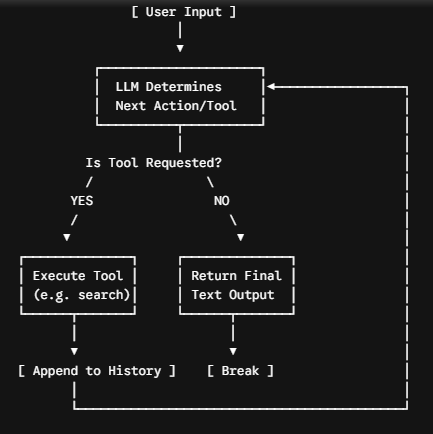